In [2]:
import torch
t_one = torch.tensor([1, 2, 3, 4, 5, 6])
t_two = torch.tensor([7, 8, 9, 10, 11, 12])

# Operation
result = t_one + t_two
print(result) # very straightforward

# similarly
result = t_one * t_two
print(result) # element-wise multiplication

# also vector can be multiplied by a scalar
result = t_one * 2
print(result)


# dot product
result = torch.dot(t_one, t_two)
print(result)

tensor([ 8, 10, 12, 14, 16, 18])
tensor([ 7, 16, 27, 40, 55, 72])
tensor([ 2,  4,  6,  8, 10, 12])
tensor(217)


In [3]:
torch.linspace(0, 10, steps=50)
# This creates a tensor with 50 evenly spaced values between 0 and 10.
# parameters:
# start: the starting value of the sequence (0 in this case)
# end: the ending value of the sequence (10 in this case)
# steps: the number of values to generate (50 in this case)

tensor([ 0.0000,  0.2041,  0.4082,  0.6122,  0.8163,  1.0204,  1.2245,  1.4286,
         1.6327,  1.8367,  2.0408,  2.2449,  2.4490,  2.6531,  2.8571,  3.0612,
         3.2653,  3.4694,  3.6735,  3.8776,  4.0816,  4.2857,  4.4898,  4.6939,
         4.8980,  5.1020,  5.3061,  5.5102,  5.7143,  5.9184,  6.1224,  6.3265,
         6.5306,  6.7347,  6.9388,  7.1429,  7.3469,  7.5510,  7.7551,  7.9592,
         8.1633,  8.3673,  8.5714,  8.7755,  8.9796,  9.1837,  9.3878,  9.5918,
         9.7959, 10.0000])

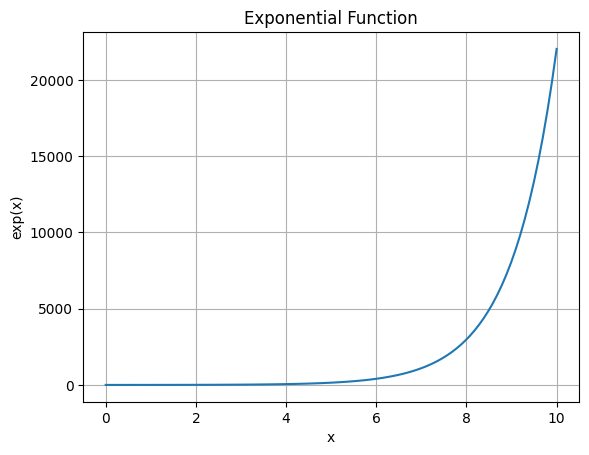

In [5]:
x = torch.linspace(0, 10, steps=100)
y = torch.exp(x)

# plot it
import matplotlib.pyplot as plt

plt.plot(x.numpy(), y.numpy()) # here why .numpy()? bcz matplotlib works with numpy arrays
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Exponential Function')
plt.grid(True)
plt.show()

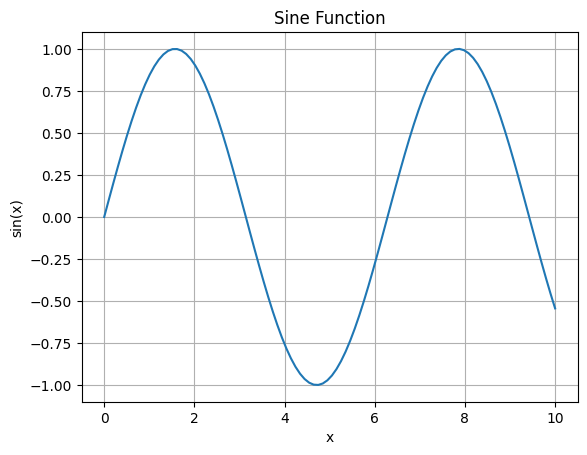

In [6]:
x = torch.linspace(0, 10, steps=100)
y = torch.sin(x)


plt.plot(x.numpy(), y.numpy()) # here why .numpy()? bcz matplotlib works with numpy arrays
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Sine Function')
plt.grid(True)
plt.show()

In [12]:
# 2D tensor
# Eg.: Grey scale image --> 2 d pixel values
# refer https://www.analyticsvidhya.com/blog/2021/03/grayscale-and-rgb-format-for-storing-images/
# image https://share.google/images/vrdBKVXuorIGppmYm

# 0 means no color (black)
# 255 means full color (white)

one_d = torch.arange(0, 9) # here parameter : start, end and step
one_d # tensor([2, 3, 4, 5, 6])

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [19]:
# view as 2D
two_d =one_d.view(3,3)
print(two_d)
# confirm the dimensions
two_d.dim() # 2

# slicing
two_d[0, 0] # 0
two_d[0, 1] # 1
two_d[0, 2] # 2
two_d[1, 0] # 3
two_d[1, 1] # 4
two_d[1, 2] # 5
two_d[2, 0] # 6
two_d[2, 1] # 7
two_d[2, 2] # 8


tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


tensor(8)

In [21]:
x = torch.arange(18).view(3, 3, 2)
print(x)

# you can compare this with excel sheet - each 2D slice is like a sheet
# 3: 2D tensor with shape (3, 2) here 3 means number of sheets


tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])


In [22]:
# slicing 3D
x = torch.arange(18).view(3, 2, 3)
print(x)

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]]])


In [29]:
# select the first 2D slice (first 'sheet') of the 3D tensor x
x[2, :, :] # means the third 2D slice (0-indexed) of the 3D tensor



tensor([[12, 13, 14],
        [15, 16, 17]])

In [ ]:
x[2,:1,:1] # means the first row and first column of the third 2D slice

tensor([], size=(1, 0), dtype=torch.int64)

In [ ]:
x[1,0:1,:] # means the second 2D slice, first row, all columns
 # here 1 means the first row (0-indexed)
 # 0:1 means the first element (0-indexed) to the second element (1-indexed)
 

tensor([[6, 7, 8]])

In [37]:
# matrix multiplication

# create two 2D tensors (matrices)
A = torch.tensor([[1, 2, 3], [4, 5, 6]])
B = torch.tensor([[7, 8], [9, 10], [11, 12]])

# perform matrix multiplication
C = torch.matmul(A, B)
C


tensor([[ 58,  64],
        [139, 154]])

In [ ]:
A = torch.tensor([[1, 2, 3], [4, 5, 6]])
B = torch.tensor([[1, 2]])
C = torch.matmul(A, B.T) # B.T is the transpose of B

# Reference 
# https://www.geeksforgeeks.org/cpp/cpp-matrix-multiplication/
# https://www.youtube.com/watch?v=M5TsRZt3mis
# https://www.shiksha.com/online-courses/articles/matrix-multiplication-a-beginners-guide-to-understand-and-implement/
C

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x3 and 2x1)

In [47]:
# derivatives or gradients
# first understand what is derivative
import re


x = torch.tensor(1.0, requires_grad=True) # why requires_grad=True? because we want to compute the gradient
z = torch.tensor(2.0, requires_grad=True)
y= 9*x**4 + z**3
y.backward() # compute the derivative
x.grad # dy/dx at x=1.0
z.grad # dy/dz at z=2.0


tensor(12.)

In [ ]:
# partial derivatives
x.grad 

#this concepts is very usefull when you want to optimize a function with respect to its inputs

tensor(36.)